In [41]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt



In [3]:
from google.colab import files
import zipfile
import os

# Upload the file
uploaded = files.upload()

# Extract the uploaded file
for data_set in uploaded.keys():
    with zipfile.ZipFile(data_set, 'r') as zip_ref:
        zip_ref.extractall()  # Extracts into the current directory
    print(f"Extracted {data_set}")


Saving archive (7).zip to archive (7).zip
Extracted archive (7).zip


In [4]:
from google.colab import files
import zipfile
import os

# Upload the file
uploaded = files.upload()

# Extract the uploaded file
for data_set in uploaded.keys():
    with zipfile.ZipFile(data_set, 'r') as zip_ref:
        zip_ref.extractall()  # Extracts into the current directory
    print(f"Extracted {data_set}")

Saving Dataset.zip to Dataset.zip
Extracted Dataset.zip


In [31]:
import os
import shutil
import random

# Set the paths to your dataset directories
# train_dir = "path/to/train"
# test_dir = "path/to/test"

train_dir = '/content/train'
test_dir = '/content/test'

# Set the paths for the new dataset directories
# new_train_dir = "path/to/new_train"
# new_test_dir = "path/to/new_test"

new_train_dir = '/content/Dataset/new_train'
new_test_dir = '/content/Dataset/new_test'

# Create new directories if they don't exist
os.makedirs(new_train_dir, exist_ok=True)
os.makedirs(new_test_dir, exist_ok=True)

# Function to select and copy 1000 images from each folder
def select_and_copy_images(source_dir, target_dir, num_images=4000):
    for folder_name in os.listdir(source_dir):
        folder_path = os.path.join(source_dir, folder_name)
        target_folder_path = os.path.join(target_dir, folder_name)
        os.makedirs(target_folder_path, exist_ok=True)

        # List all image files in the folder
        images = os.listdir(folder_path)
        images = [img for img in images if img.endswith(('.png', '.jpg', '.jpeg'))]

        # Select num_images randomly or sequentially
        # selected_images = random.sample(images, num_images)  # Randomly selects
        selected_images = images[:num_images]  # Sequentially selects first 1000

        # Copy selected images to the new directory
        for img in selected_images:
            shutil.copy(os.path.join(folder_path, img), os.path.join(target_folder_path, img))

# Select and copy images for both train and test datasets
select_and_copy_images(train_dir, new_train_dir, num_images=1000)
select_and_copy_images(test_dir, new_test_dir, num_images=1000)

print("Image selection and copying completed.")

Image selection and copying completed.


In [32]:
# 2. Data Augmentation
datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.15  # Split for validation
)

In [33]:
# 3. Load Training and Validation Data
batch_size = 32
train_generator = datagen.flow_from_directory(
    # 'path_to_dataset',  # Replace with the path to your dataset
    new_train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='sparse',
    subset='training')

validation_generator = datagen.flow_from_directory(
    # 'path_to_dataset',  # Replace with the path to your dataset
    new_train_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation')


Found 10186 images belonging to 7 classes.
Found 1794 images belonging to 7 classes.


In [ ]:
# 1. Define the CNN Model - type 01
def create_emotion_cnn(input_shape=(48, 48, 1)):
    model = Sequential()

    # First Convolutional Block
    model.add(Conv2D(32, (3, 3), activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Second Convolutional Block
    model.add(Conv2D(64, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Third Convolutional Block
    model.add(Conv2D(128, (3, 3), activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Dropout(0.25))

    # Flatten and Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(7, activation='softmax'))  # 7 output classes for the emotions

    return model

In [42]:
# 1. Define the CNN Model - type 02
model = Sequential()
model.add(Conv2D(32,(3,3), activation = 'relu', input_shape = (150, 150, 3)))
model.add(Conv2D(64, (3,3), activation = 'relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(64,(3,3), activation = 'relu'))
model.add(Conv2D(64,(3,3), activation = 'relu'))
model.add(Dropout(0.3))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3), activation = 'relu'))
model.add(Conv2D(128,(3,3), activation = 'relu'))
model.add(Conv2D(128,(3,3), activation = 'relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Conv2D(128,(3,3), activation = 'relu'))
model.add(Conv2D(128,(3,3), activation = 'relu'))
model.add(MaxPooling2D(2,2))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(512, activation = 'relu'))
model.add(Dense(512, activation = 'relu'))
model.add(Dropout(0.3))
model.add(Dense(4, activation = 'softmax'))

In [51]:
# Create and compile the model
model = create_emotion_cnn()
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [43]:
# Print model summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)                    │ (None, 148, 148, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 146, 146, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 73, 73, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 71, 71, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_9 (Conv2D)                    │ (None, 69, 69, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 69, 69, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 34, 34, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 34, 34, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_10 (Conv2D)                   │ (None, 32, 32, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_11 (Conv2D)                   │ (None, 30, 30, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_12 (Conv2D)                   │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_13 (Conv2D)                   │ (None, 12, 12, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_14 (Conv2D)                   │ (None, 10, 10, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_9 (MaxPooling2D)       │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 5, 5, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 3200)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 512)                 │       1,638,912 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 2,661,060 (10.15 MB)

 Trainable params: 2,661,060 (10.15 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
# 4. Train the Model
# epochs = 25
epochs = 10
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator
)


Epoch 1/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 72s 214ms/step - accuracy: 0.2092 - loss: 2.5768 - val_accuracy: 0.2369 - val_loss: 1.9120
Epoch 2/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 63s 197ms/step - accuracy: 0.2765 - loss: 1.9551 - val_accuracy: 0.3445 - val_loss: 1.7119
Epoch 3/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 82s 196ms/step - accuracy: 0.3336 - loss: 1.7496 - val_accuracy: 0.3668 - val_loss: 1.6565
Epoch 4/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 65s 203ms/step - accuracy: 0.3839 - loss: 1.6566 - val_accuracy: 0.3322 - val_loss: 1.7212
Epoch 5/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 63s 197ms/step - accuracy: 0.4162 - loss: 1.5823 - val_accuracy: 0.4125 - val_loss: 1.5929
Epoch 6/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 86s 209ms/step - accuracy: 0.4413 - loss: 1.5294 - val_accuracy: 0.3896 - val_loss: 1.6104
Epoch 7/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 65s 204ms/step - accuracy: 0.4591 - loss: 1.4976 - val_accuracy: 0.3679 - val_loss: 1.6732
Epoch 8/10
319/319 ━━━━━━━━━━━━━━━━━━━━ 63s 197ms/step - accuracy: 0.4660 - loss: 1

In [54]:
# 5. Evaluate the Model
test_generator = datagen.flow_from_directory(
    # 'path_to_dataset',  # Replace with the path to your dataset
    new_test_dir,
    target_size=(48, 48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='sparse',
    subset='validation')

loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy * 100:.2f}%")


Found 883 images belonging to 7 classes.
28/28 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.4405 - loss: 1.4848
Test Accuracy: 42.24%


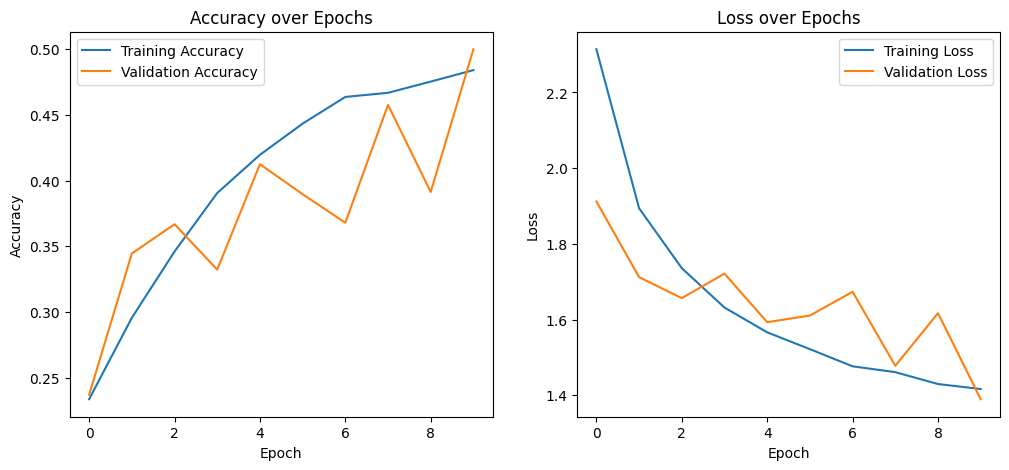

In [55]:
# 6. Visualize Training History
# Plot training accuracy and loss
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


In [56]:
# 7. Save the Model
model.save('emotion_cnn_model.h5')


In [57]:
# 8. Load and Use the Model for Inference
from tensorflow.keras.models import load_model
import numpy as np
from tensorflow.keras.preprocessing import image


In [58]:
# Load the saved model
model = load_model('emotion_cnn_model.h5')


In [63]:
# Load a sample image for prediction
# img_path = '/content/cr.jpg'  # Replace with the path to your image
# img_path = '/content/hpf.jpg'
img_path = '/content/hpf2.jpg'
img = image.load_img(img_path, target_size=(48, 48), color_mode='grayscale')
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0


In [64]:
# Make a prediction
predictions = model.predict(img_array)
emotion_labels = ['Angry', 'Happy', 'Sad', 'Disgust', 'Fear', 'Neutral', 'Surprise']
predicted_emotion = emotion_labels[np.argmax(predictions)]

print(f"Predicted Emotion: {predicted_emotion}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Predicted Emotion: Neutral
